In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Feature importance analysis
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder


In [2]:
df = pd.read_csv('/Users/malu/Desktop/NITC/Year_3/ML/tennis.csv')

# Basic data exploration
print(df.head())
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# View unique values in categorical columns for understanding
for col in df.select_dtypes(include=['object']).columns:
    print(f"Unique values in {col}: {df[col].unique()}")

   rally  serve hitpoint      speed  net.clearance  distance.from.sideline  \
0      4      1        B  35.515042      -0.021725                3.474766   
1      4      2        B  33.382640       1.114202                2.540801   
2     23      1        B  22.316690      -0.254046                3.533166   
3      9      1        F  36.837309       0.766694                0.586885   
4      4      1        B  35.544208       0.116162                0.918725   

      depth  outside.sideline  outside.baseline  player.distance.travelled  \
0  6.797621             False             False                   1.467570   
1  2.608708             False              True                   2.311931   
2  9.435749             False             False                   3.903728   
3  3.342180              True             False                   0.583745   
4  5.499119             False             False                   2.333456   

   ...  previous.depth  opponent.depth  opponent.distance.from

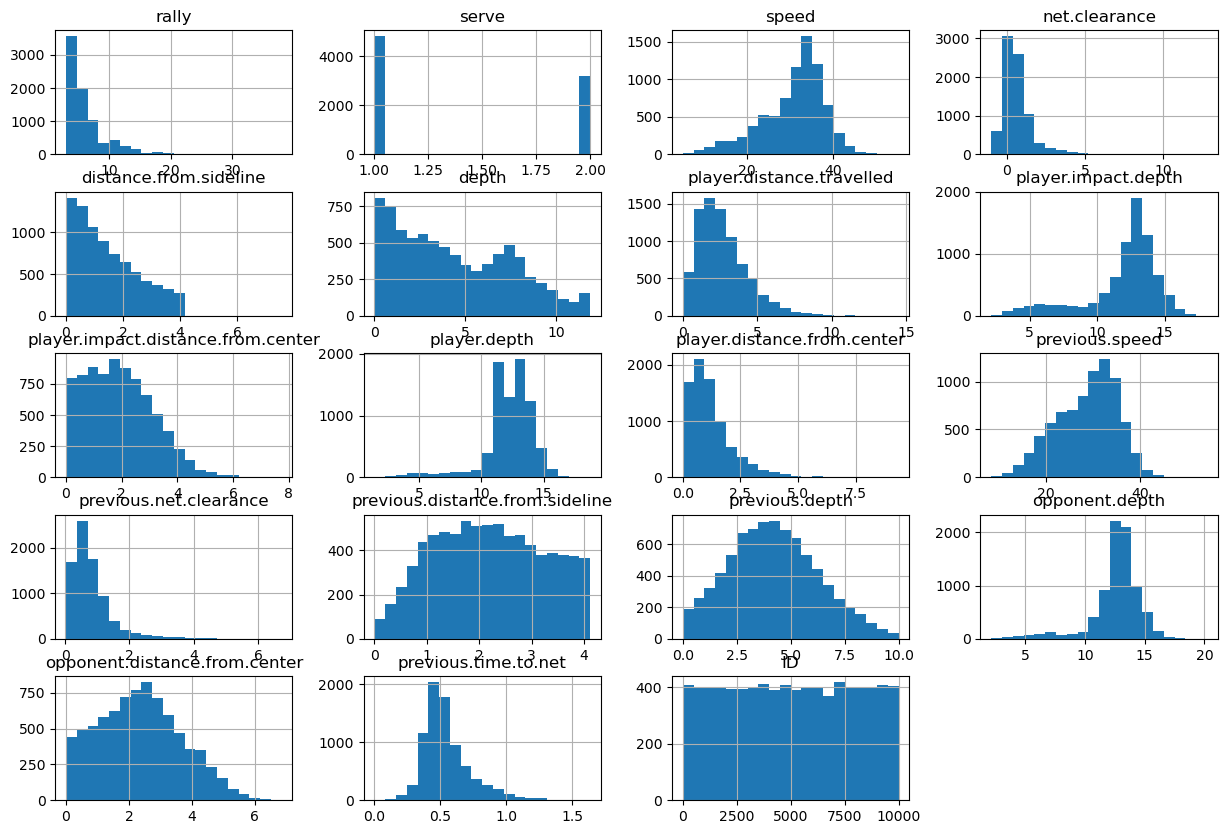

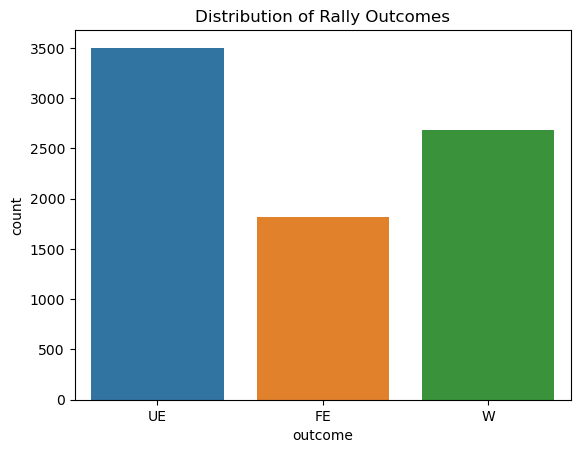

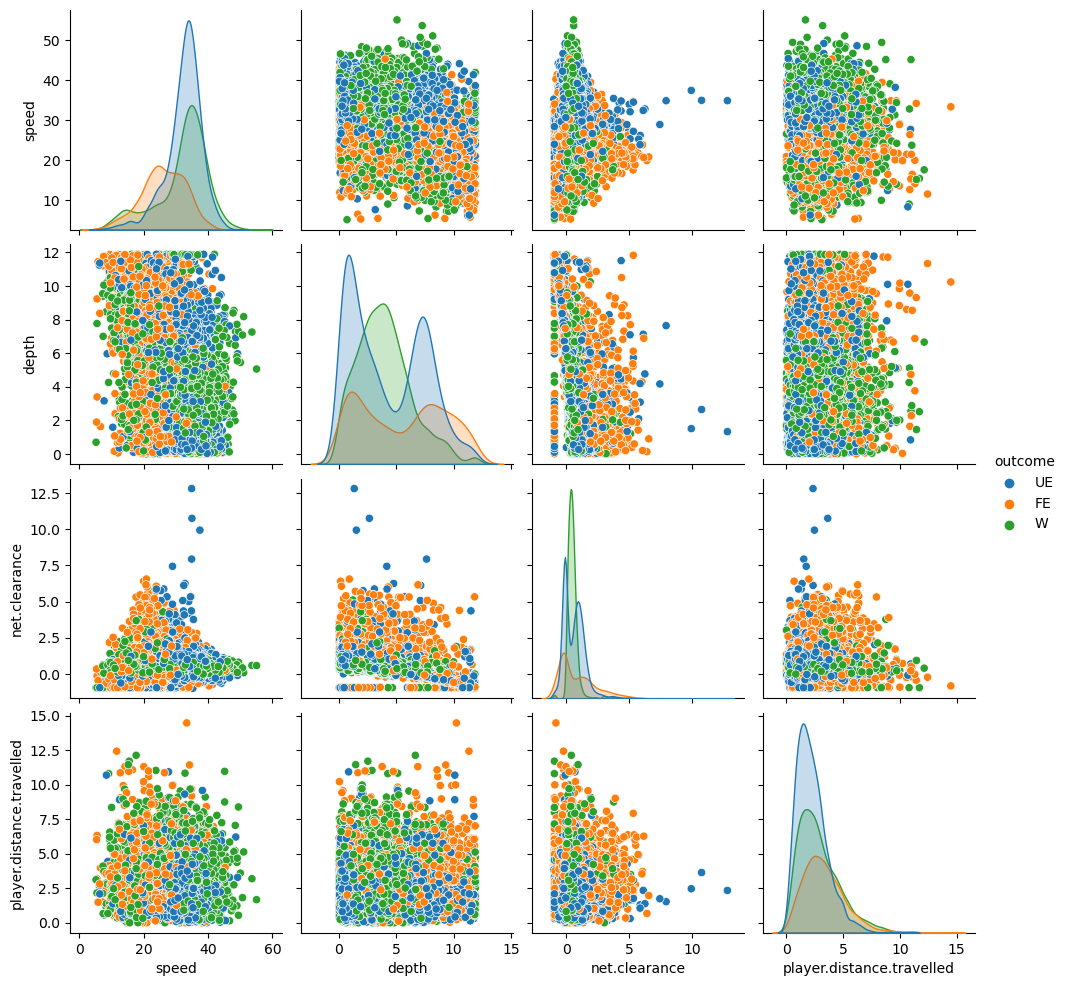

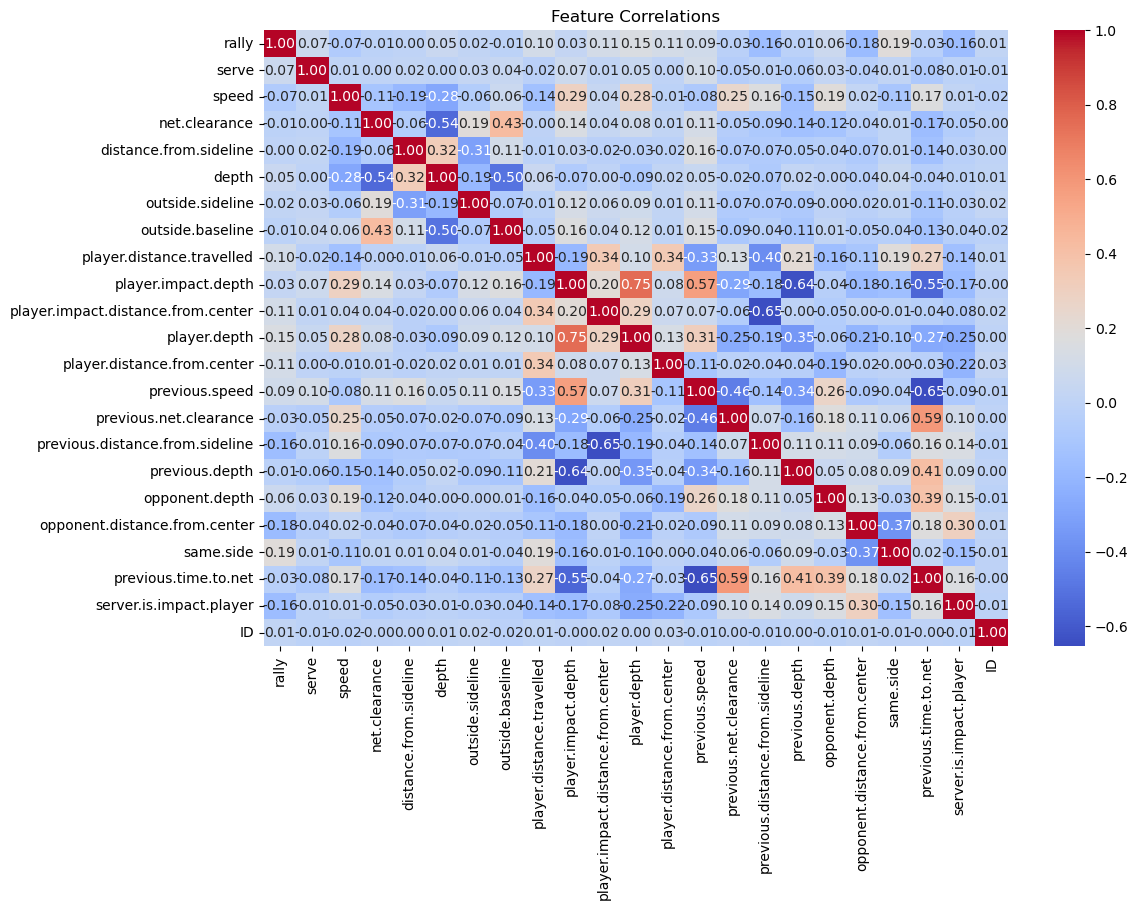

In [3]:
# Visualize distributions of numerical features
df.hist(bins=20, figsize=(15, 10))
plt.show()

# Count plot for target variable 'outcome'
sns.countplot(data=df, x='outcome')
plt.title('Distribution of Rally Outcomes')
plt.show()

# Pairplot for selected numerical columns
sns.pairplot(df, vars=['speed', 'depth', 'net.clearance', 'player.distance.travelled'], hue='outcome')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlations')
plt.show()

In [4]:
df.columns

Index(['rally', 'serve', 'hitpoint', 'speed', 'net.clearance',
       'distance.from.sideline', 'depth', 'outside.sideline',
       'outside.baseline', 'player.distance.travelled', 'player.impact.depth',
       'player.impact.distance.from.center', 'player.depth',
       'player.distance.from.center', 'previous.speed',
       'previous.net.clearance', 'previous.distance.from.sideline',
       'previous.depth', 'opponent.depth', 'opponent.distance.from.center',
       'same.side', 'previous.hitpoint', 'previous.time.to.net',
       'server.is.impact.player', 'outcome', 'gender', 'ID'],
      dtype='object')

In [5]:
# Automatically detect categorical and numerical columns
if 'ID' in df.columns:
    X = df.drop(columns=['outcome', 'ID'])  # Drop target and ID columns if ID is present
else:
    X = df.drop(columns=['outcome'])        # Only drop 'outcome' if 'ID' is not present
y = df['outcome']

# Automatically detect categorical and numerical columns
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numeric_features = X.select_dtypes(include=[np.number]).columns

# Print column verification
print("Categorical features detected:", categorical_features.tolist())
print("Numeric features detected:", numeric_features.tolist())

# Preprocessing pipeline for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with mean for numeric columns
    ('scaler', StandardScaler())                  # Standardize numeric columns for models sensitive to feature scaling
])

# Preprocessing pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with the most frequent value for categorical columns
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # One-hot encode categorical columns
])

# Combine preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Columns in X after dropping 'outcome' and 'ID':", X.columns)
print("Data types in X:\n", X.dtypes)



print("Categorical features detected:", categorical_features)
print("Numeric features detected:", numeric_features)
# Apply the transformations to the features
X = preprocessor.fit_transform(X)  # Apply the preprocessing pipeline




Categorical features detected: ['hitpoint', 'outside.sideline', 'outside.baseline', 'same.side', 'previous.hitpoint', 'server.is.impact.player', 'gender']
Numeric features detected: ['rally', 'serve', 'speed', 'net.clearance', 'distance.from.sideline', 'depth', 'player.distance.travelled', 'player.impact.depth', 'player.impact.distance.from.center', 'player.depth', 'player.distance.from.center', 'previous.speed', 'previous.net.clearance', 'previous.distance.from.sideline', 'previous.depth', 'opponent.depth', 'opponent.distance.from.center', 'previous.time.to.net']
Columns in X after dropping 'outcome' and 'ID': Index(['rally', 'serve', 'hitpoint', 'speed', 'net.clearance',
       'distance.from.sideline', 'depth', 'outside.sideline',
       'outside.baseline', 'player.distance.travelled', 'player.impact.depth',
       'player.impact.distance.from.center', 'player.depth',
       'player.distance.from.center', 'previous.speed',
       'previous.net.clearance', 'previous.distance.from.sid

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Neural Network": MLPClassifier(max_iter=200),
    "Bagging": BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=10)
}

# Train, evaluate, and compare models
results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1
    })

# Create DataFrame for comparison
results_df = pd.DataFrame(results)
print(results_df)

/Applications/software/python/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
/Applications/software/python/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


                    Model  Accuracy    Recall  Precision  F1 Score
0     Logistic Regression  0.821362  0.805311   0.817080  0.809018
1           Decision Tree  0.795128  0.783265   0.787121  0.785073
2           Random Forest  0.849469  0.838568   0.842991  0.840214
3       Gradient Boosting  0.859463  0.848030   0.853594  0.850038
4  Support Vector Machine  0.841974  0.832616   0.836348  0.833306
5     K-Nearest Neighbors  0.739538  0.724388   0.735434  0.725829
6          Neural Network  0.850718  0.844400   0.845619  0.844893
7                 Bagging  0.839475  0.832572   0.832338  0.832450


In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
numeric_cols = ['rally', 'serve', 'speed', 'net.clearance', 'distance.from.sideline', 'depth', 'player.distance.travelled', 'player.impact.depth', 'player.impact.distance.from.center', 'player.depth', 'player.distance.from.center', 'previous.speed', 'previous.net.clearance', 'previous.distance.from.sideline', 'previous.depth', 'opponent.depth', 'opponent.distance.from.center', 'previous.time.to.net']
categorical_cols = ['hitpoint', 'outside.sideline', 'outside.baseline', 'same.side', 'previous.hitpoint', 'server.is.impact.player', 'gender']
all_feature_names = numeric_cols + categorical_cols

rf_model = RandomForestClassifier().fit(X_train, y_train)

# Feature importances from Random Forest
importances = rf_model.feature_importances_

# Get sorted indices of the top 5 most important features
sorted_indices = importances.argsort()[-5:]
top_features_rf = [all_feature_names[i] for i in sorted_indices]
print("Top 5 important features based on Random Forest:", top_features_rf)

# Permutation importance
perm_importance = permutation_importance(rf_model, X_test, y_test)
perm_sorted_idx = perm_importance.importances_mean.argsort()[-5:]
top_features_perm = [all_feature_names[i] for i in perm_sorted_idx]
print("Top 5 important features based on permutation importance:", top_features_perm)

Top 5 important features based on Random Forest: ['previous.hitpoint', 'server.is.impact.player', 'speed', 'previous.time.to.net', 'net.clearance']
Top 5 important features based on permutation importance: ['speed', 'previous.hitpoint', 'previous.time.to.net', 'server.is.impact.player', 'net.clearance']


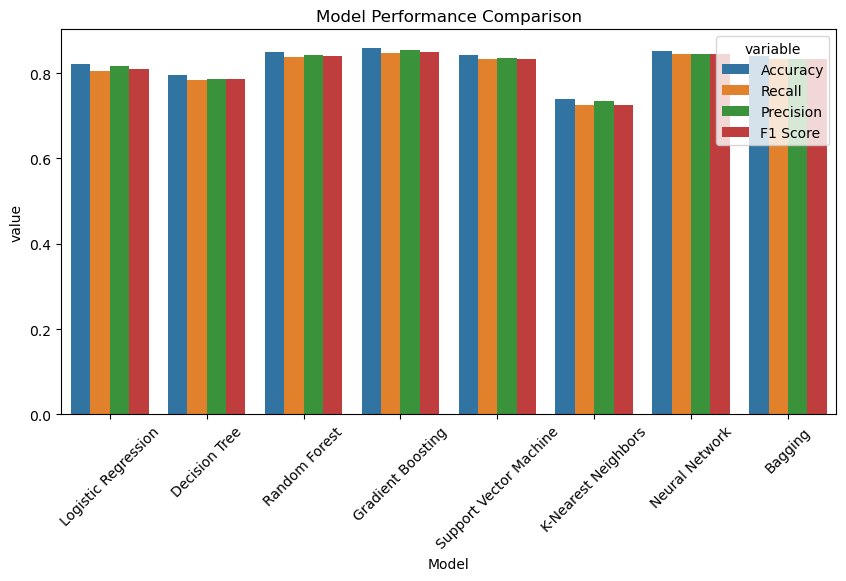

In [9]:
# Visualize Model Performance
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df.melt(id_vars=["Model"]), x="Model", y="value", hue="variable")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()